## Exploratory Data Analysis (EDA)
Datasets explored:
- Raw synthetic supplier-commodity dataset
- Preprocessed synthetic supplier-commodity dataset
- Feature engineered synthetic supplier-commodity dataset

### Raw Synthetic Supplier-Commodity Dataset
The initial dataset generated by ChatGPT with the `synthetic_dataset_prompt.txt`

In [2]:
# Analyse nature of dataset
# Check for missing values, noise, inconsistencies, etc.
# Check for class imbalance
# Identify existing patterns and relationships
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATASET_PATH = Path("../data/raw/syn_supplier_commodity_dataset.csv")
raw_df = pd.read_csv(DATASET_PATH)
raw_df = pd.DataFrame(raw_df)

# This is to ensure that Jupyter doesn't truncate the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


In [3]:
# Basic information about the generated dataset
print("==== BASIC INFORMATION ====")
raw_df.info()
print(f"Rows:    {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")

print("\n==== FIRST 5 ROWS ====")
raw_df.head(5)

==== BASIC INFORMATION ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SC_ID                               20400 non-null  object 
 1   Supplier_Name                       20400 non-null  object 
 2   Commodity_Name                      20400 non-null  object 
 3   Year                                20400 non-null  int64  
 4   Month                               20400 non-null  object 
 5   Country                             20400 non-null  object 
 6   Region                              20400 non-null  object 
 7   Supplier_Tier                       20400 non-null  int64  
 8   Industry_Sector                     20400 non-null  object 
 9   ESG_Score                           18831 non-null  float64
 10  Environmental_Score                 19242 non-null  float64
 11  Social_Score 

,SC_ID,Supplier_Name,Commodity_Name,Year,Month,Country,Region,Supplier_Tier,Industry_Sector,ESG_Score,Environmental_Score,Social_Score,Governance_Score,Carbon_Emission_Intensity,GHG_Scope1_Intensity,GHG_Scope2_Intensity,GHG_Scope3_Intensity,Water_Intensity,Waste_Management_Efficiency,Renewable_Energy_Usage,Compliance_Level,Sustainability_Report_Availability,Certifications_Active,Lead_Time_Days,Production_Capacity,On_Time_Delivery_Rate,Defect_Rate,Incident_History_Count,Labour_Compliance_Score,Diversity_Index,Financial_Stability_Score,Freight_Cost,Cost_Index,Commodity_Price_Index,Commodity_Demand,Trade_Volume,Logistics_Distance_km,Risk_Classification
0,SC0000001,Nestlé,Packaged foods and beverages,2019,January,Switzerland,Europe and Central Asia,1,FMCG,86.6,90.6,47.2,82.8,0.222,1.55,1.49,0.88,475.2,0.85,0.31,2,1,OHSAS 18001; LEED,72,34136,1.00,0.036,1,87.6,0.27,69.0,46080.23,0.59,0.88,29847,11958,10588,Low
1,SC0000002,Reliance Industries Limited,"Polypropylene, Polyethylene, PTA",2019,January,India,South Asia,1,Petrochemicals,51.1,83.1,49.0,49.5,0.207,1.26,0.47,2.77,447.3,0.93,0.72,3,1,RSPO; ISO 50001,77,25890,0.91,0.027,0,87.8,0.21,59.7,13530.71,0.68,1.14,34545,72324,6016,Moderate
2,SC0000003,Volkswagen Group,Automobiles and automotive components,2019,January,Germany,Europe and Central Asia,1,Automotive,64.8,85.5,78.3,49.5,0.168,0.56,1.37,2.65,120.6,0.49,0.19,3,1,ISO 50001; ISO 14001,26,12074,1.00,0.018,2,88.4,0.44,68.3,38957.59,0.63,0.90,99156,30617,2107,Low
3,SC0000004,Reliance Industries Limited,"Polypropylene, Polyethylene, PTA",2019,January,India,South Asia,1,Petrochemicals,82.7,74.8,89.3,48.1,0.378,1.05,1.25,1.67,99.4,0.66,0.41,2,1,NaN,41,38926,1.00,0.036,0,68.5,0.70,68.7,45995.33,1.32,1.23,12573,58360,1881,Low
4,SC0000005,BASF,"Chemicals, plastics, specialty materials",2019,January,Germany,Europe and Central Asia,1,Chemicals,89.3,58.9,92.5,56.6,0.246,1.91,0.80,0.88,445.5,0.72,0.51,2,1,ISO 14001; RSPO,71,34191,1.00,0.018,3,79.0,0.45,81.3,26659.78,0.54,1.11,21014,57194,10862,Low


In [4]:
# Descriptive analysis
print("\n===== DESCRIPTIVE STATISTICS (NUMERIC) =====")
display(raw_df.describe())

print("\n===== DESCRIPTIVE STATISTICS (CATEGORICAL) =====")
display(raw_df.describe(include='object'))

print("\n===== DATA TYPES =====")
print(raw_df.dtypes)

# Check no. of unique values for each column
print("\n===== UNIQUE VALUES PER COLUMN =====")
print(raw_df.nunique())


===== DESCRIPTIVE STATISTICS (NUMERIC) =====


,Year,Supplier_Tier,ESG_Score,Environmental_Score,Social_Score,Governance_Score,Carbon_Emission_Intensity,GHG_Scope1_Intensity,GHG_Scope2_Intensity,GHG_Scope3_Intensity,Water_Intensity,Waste_Management_Efficiency,Renewable_Energy_Usage,Compliance_Level,Sustainability_Report_Availability,Lead_Time_Days,Production_Capacity,On_Time_Delivery_Rate,Defect_Rate,Incident_History_Count,Labour_Compliance_Score,Diversity_Index,Financial_Stability_Score,Freight_Cost,Cost_Index,Commodity_Price_Index,Commodity_Demand,Trade_Volume,Logistics_Distance_km
count,20400.000000,20400.0,18831.000000,19242.000000,19242.000000,19242.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,19039.000000,20400.000000,19414.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,2021.433431,1.0,73.990489,63.337875,66.831852,69.795567,0.214614,1.664917,1.161732,2.478214,274.153936,0.674246,0.472581,1.483775,0.696422,50.203529,27536.868922,0.809726,0.050254,2.646961,78.984101,0.524039,75.054244,27378.087370,0.998809,1.100256,54907.998235,42693.833186,7755.759265
std,1.680226,0.0,13.767233,16.278041,14.723135,13.244194,0.144650,0.975420,0.697743,1.346263,130.309829,0.158526,0.216390,1.120003,0.459814,23.384702,13021.360913,0.189041,0.031952,2.271677,10.941442,0.187440,11.548953,12982.674512,0.288447,0.173083,25919.362404,21676.850383,4179.552471
min,2019.000000,1.0,40.200000,28.000000,35.000000,42.000000,0.010000,0.250000,0.150000,0.500000,50.000000,0.400000,0.100000,0.000000,0.000000,10.000000,5008.000000,0.500000,0.005000,0.000000,60.000000,0.200000,55.000000,5001.250000,0.500000,0.800000,10008.000000,5007.000000,500.000000
25%,2020.000000,1.0,62.700000,49.600000,54.300000,58.400000,0.105000,0.930000,0.640000,1.480000,160.800000,0.540000,0.290000,0.000000,0.000000,30.000000,16181.500000,0.640000,0.027000,1.000000,69.500000,0.360000,65.100000,16049.542500,0.750000,0.950000,32505.500000,23955.000000,4132.750000
50%,2021.000000,1.0,73.900000,63.300000,66.800000,69.600000,0.192000,1.490000,1.040000,2.220000,273.650000,0.680000,0.470000,1.000000,1.000000,50.000000,27638.500000,0.860000,0.043000,2.000000,78.900000,0.520000,75.100000,27416.160000,1.000000,1.100000,54918.500000,42710.500000,7735.000000
75%,2023.000000,1.0,85.200000,77.000000,79.200000,81.100000,0.288000,2.150000,1.510000,3.130000,387.325000,0.810000,0.660000,2.000000,1.000000,71.000000,38802.250000,1.000000,0.067000,4.000000,88.400000,0.690000,85.100000,38663.347500,1.250000,1.250000,77125.750000,61620.000000,11385.000000
max,2024.000000,1.0,104.900000,95.000000,95.000000,95.000000,0.750000,5.250000,3.750000,7.490000,500.000000,0.950000,0.850000,3.000000,1.000000,90.000000,50000.000000,1.000000,0.150000,13.000000,98.000000,0.850000,95.000000,49999.640000,1.500000,1.400000,99999.000000,79994.000000,15000.000000



===== DESCRIPTIVE STATISTICS (CATEGORICAL) =====


,SC_ID,Supplier_Name,Commodity_Name,Month,Country,Region,Industry_Sector,Certifications_Active,Risk_Classification
count,20400,20400,20400,20400,20400,20400,20400,18423,20400
unique,20000,20,19,12,13,7,16,56,3
top,SC0000334,Wilmar International,Crude palm oil,April,United States,East Asia and Pacific,Agriculture,OHSAS 18001,High
freq,3,1954,1954,1748,2890,6836,2940,1393,10177



===== DATA TYPES =====
SC_ID                                  object
Supplier_Name                          object
Commodity_Name                         object
Year                                    int64
Month                                  object
Country                                object
Region                                 object
Supplier_Tier                           int64
Industry_Sector                        object
ESG_Score                             float64
Environmental_Score                   float64
Social_Score                          float64
Governance_Score                      float64
Carbon_Emission_Intensity             float64
GHG_Scope1_Intensity                  float64
GHG_Scope2_Intensity                  float64
GHG_Scope3_Intensity                  float64
Water_Intensity                       float64
Waste_Management_Efficiency           float64
Renewable_Energy_Usage                float64
Compliance_Level                        int64
Sustainabi

In [5]:
# Types of industries
print("\n===== TYPES OF INDUSTRIES =====")
print(raw_df['Industry_Sector'].value_counts())

# Regions available
print("\n===== ALL REGIONS =====")
print(raw_df['Region'].value_counts())


===== TYPES OF INDUSTRIES =====
Industry_Sector
Agriculture                      2940
Automotive                       1974
Metals and Mining                1915
Oil and Gas                      1899
FMCG                             1009
Oil and Gas/Refining             1005
Automotive/EV                     989
Electronics/Manufacturing         982
Cement and Building Materials     973
Electronics/Semiconductors        973
Semiconductors                    969
Automotive/Energy                 965
Petrochemicals/Polymers           964
Petrochemicals                    953
Steel/Materials                   951
Chemicals                         939
Name: count, dtype: int64

===== ALL REGIONS =====
Region
East Asia and Pacific                                  6836
Europe and Central Asia                                2946
North America                                          2890
Middle East, North Africa, Afghanistan and Pakistan    1969
Sub-Saharan Africa                           

===== MISSING VALUES =====
Certifications_Active                 1977
ESG_Score                             1569
Labour_Compliance_Score               1361
Governance_Score                      1158
Environmental_Score                   1158
Social_Score                          1158
Financial_Stability_Score              986
Month                                    0
Country                                  0
Commodity_Name                           0
Supplier_Name                            0
SC_ID                                    0
Year                                     0
Industry_Sector                          0
GHG_Scope1_Intensity                     0
GHG_Scope2_Intensity                     0
GHG_Scope3_Intensity                     0
Water_Intensity                          0
Waste_Management_Efficiency              0
Supplier_Tier                            0
Region                                   0
Carbon_Emission_Intensity                0
Sustainability_Report_Avail

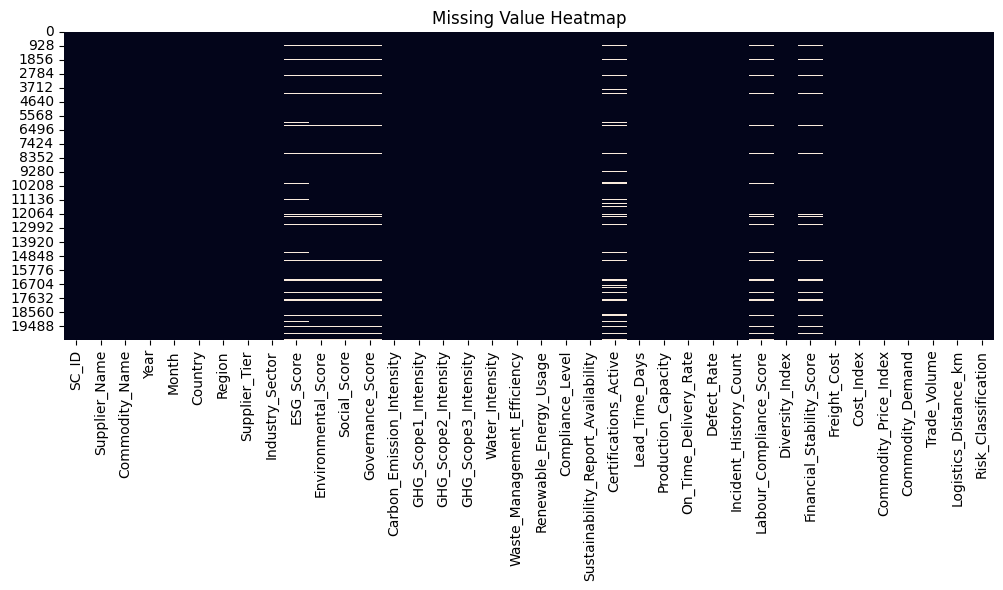

In [6]:
# Check of missing values
print("===== MISSING VALUES =====")
missing = raw_df.isna().sum().sort_values(ascending=False)
print(missing)

plt.figure(figsize=(12,4))
sns.heatmap(raw_df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [7]:
# Check for noise and inconsistencies
print(f"Total no. of duplicated rows: {raw_df.duplicated().sum()}")

# Negative columns
numeric_cols = raw_df.select_dtypes(include=np.number).columns

print("\nNegative Values:")
for col in numeric_cols:
    neg_count = (raw_df[col] < 0).sum()
    if neg_count > 0:
        print(f"Column {col} has {neg_count} negative entries.")
if neg_count == 0:
    print(f"No negative values were found.")

# Check year range
if "Year" in raw_df.columns:
    print(f"\nYear range: {raw_df["Year"].min()} to {raw_df["Year"].max()}")


Total no. of duplicated rows: 400

Negative Values:
No negative values were found.

Year range: 2019 to 2024


===== CLASS IMBALANCE CHECK =====


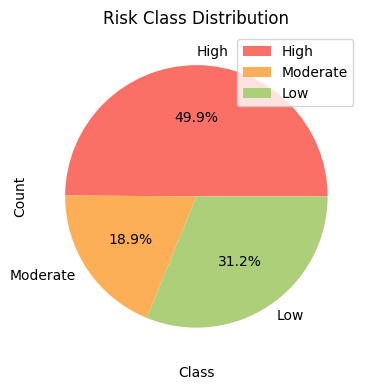

Imbalance ratio (majority/minority): 2.63 [High: 10,177 vs Moderate: 3,863]


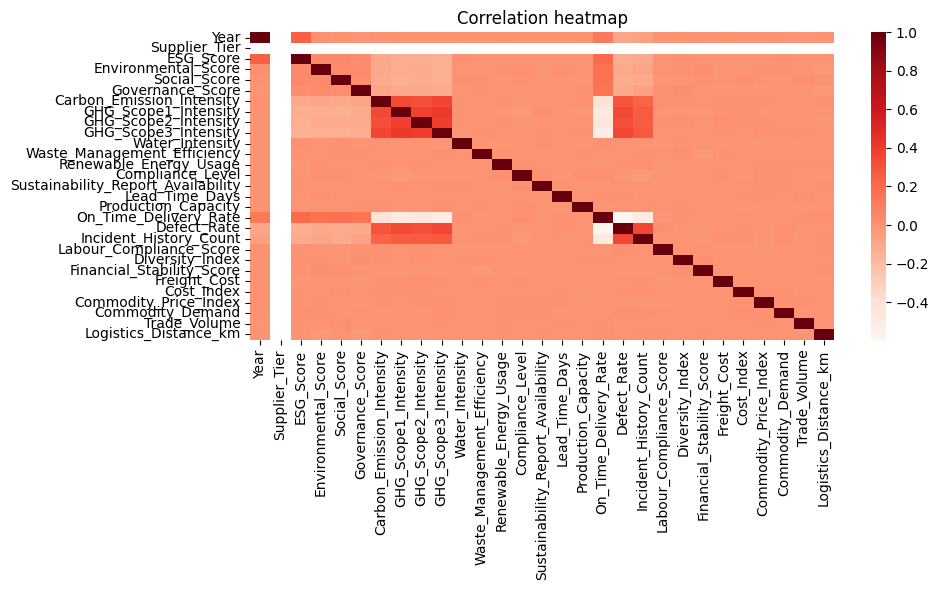

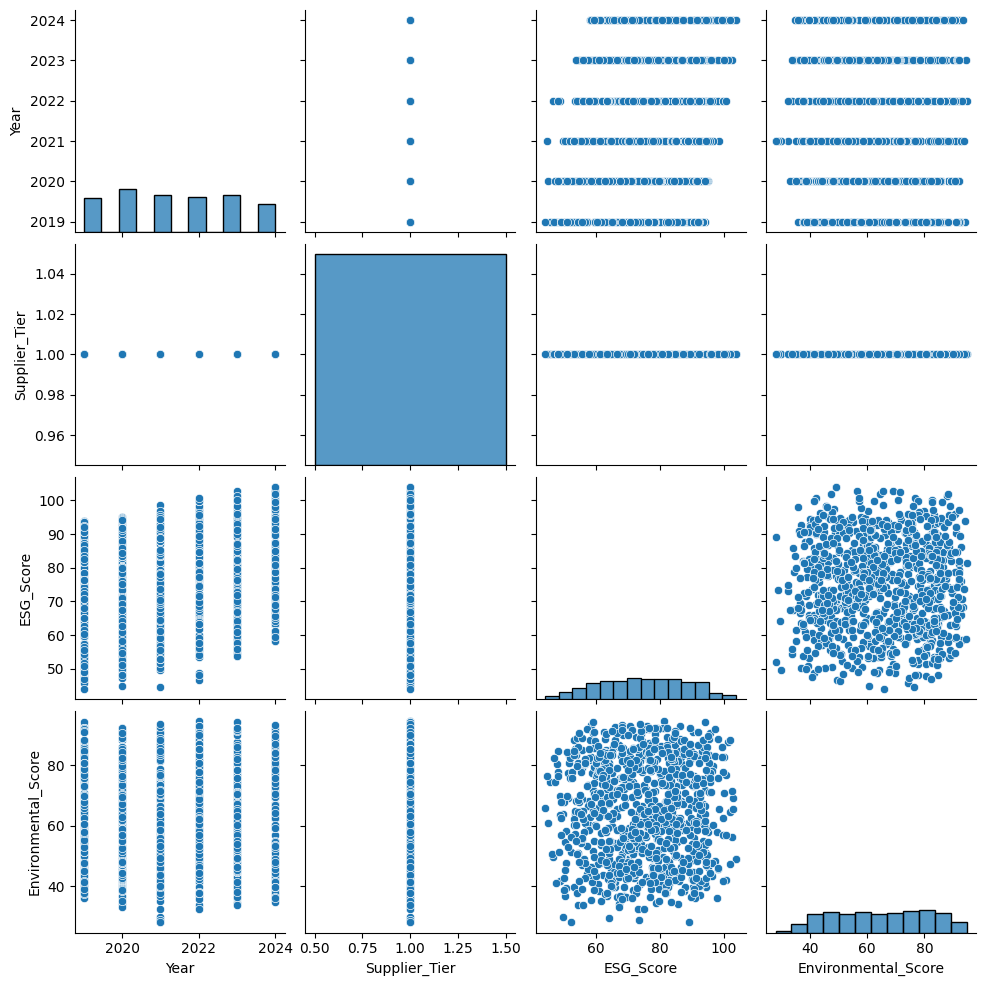

C:\Users\amtan\AppData\Local\Temp\ipykernel_5784\1913523568.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x=risk_col, order=order or None, palette=palette or None)


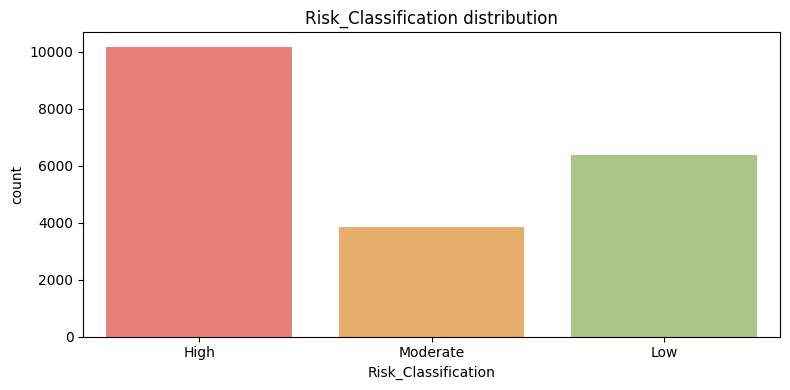

In [8]:
# Check for class imbalance
# Colour mapping for risk classes
risk_labels = ["High", "Moderate", "Low"]
risk_colours = {
    'High': "#fa7066",
    'Moderate': "#fcaf56",
    'Low': "#adcf7a",
}

print("===== CLASS IMBALANCE CHECK =====")
target_col = raw_df["Risk_Classification"]
risk_counts = target_col.value_counts().reindex(risk_labels).dropna()
risk_colours = [risk_colours[label] for label in risk_counts.index]

risk_counts.plot(kind="pie", figsize=(6, 4), autopct="%.1f%%", colors=risk_colours)
plt.title("Risk Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(risk_counts.index, loc="best")
plt.tight_layout()
plt.show()

# Calculate Imbalance Ratio of risk classes (Nikpour et al., 2025)
label_counts = target_col.value_counts()
if not label_counts.empty:
    majority_class = label_counts.idxmax()
    majority_count = label_counts.max()
    minority_class = label_counts.idxmin()
    minority_count = label_counts.min()
    imbalance_ratio = (
        majority_count / minority_count if minority_count else np.inf
    )
    print(
        f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f} "
        f"[{majority_class}: {majority_count:,} vs {minority_class}: {minority_count:,}]"
    )
else:
    print("Imbalance ratio unavailable: no labelled samples found.")

# Any relationships or patterns that can be observed now?
risk_colours = {
    "high": "#fa7066",
    "moderate": "#fcaf56",
    "low": "#adcf7a",
}

numeric_df = raw_df.select_dtypes(include=np.number)

if not numeric_df.empty:
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=False, cmap="Reds")
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()

if numeric_df.shape[1] > 1 and len(numeric_df) > 1:
    sampled_numeric = numeric_df.sample(n=min(1000, len(numeric_df)), random_state=42)
    sns.pairplot(sampled_numeric.iloc[:, :4])
    plt.show()

risk_col = next((col for col in raw_df.columns if "risk" in col.lower()), None)

if risk_col:
    order = [label for label in ["High", "Moderate", "Low"] if label in raw_df[risk_col].unique()]
    palette = {label: risk_colours[label.lower()] for label in order}
    plt.figure(figsize=(8,4))
    sns.countplot(data=raw_df, x=risk_col, order=order or None, palette=palette or None)
    plt.title(f"{risk_col} distribution")
    plt.tight_layout()
    plt.show()

### Preprocessed Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after data preprocessing (data cleaning, transformation, normalisation, mapping)

### Feature engineered Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after feature engineering